In [2]:
import pandas as pd
import numpy as np
from IPython.display import display
from itertools import product
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.axes as ma
import seaborn as sns
import math

from preprocess import get_concat_results, mean_aggregate_results, MODEL_ORDER, FRAMEWORK_ORDER, make_key, set_plt_font_sizes, approx

%load_ext autoreload
%autoreload 2

pd.options.display.float_format = '{:.1f}'.format
set_plt_font_sizes()

In [3]:
tdf, edf, ldf = get_concat_results("../data/results_ultimate_%d", 1, 15, train_preserve_warmup=False, full=True)

mtdf, medf, mldf = mean_aggregate_results(tdf, edf, ldf, train_preserve_epoch=False, latency_preserve_epoch=False)

In [42]:
mldf_cc = pd.concat([mldf, median])

In [43]:
mldf_cc

,framework,model_name,phase,elapsed_time_mean,elapsed_time_median,elapsed_time_std
0,cuDNN,FullyConnectedNet,latency,0.1,0.0,0.0
1,cuDNN,SimpleConvNet,latency,0.1,0.1,0.0
2,LibTorch,FullyConnectedNet,latency,0.1,0.1,0.0
3,LibTorch,SimpleConvNet,latency,0.2,0.2,0.0
4,LibTorch,ResNet-50,latency,5.3,5.3,0.0
...,...,...,...,...,...,...
57,PyTorch_compile,DCGAN,latency,0.8,0.8,0.1
58,PyTorch_compile,DCGAN,latency_batch,173.7,174.1,7.6
0,Matlab,YOLOv8m,latency,-1.0,75.0,-1.0
1,PyTorch,YOLOv8m,latency,-1.0,56.0,-1.0


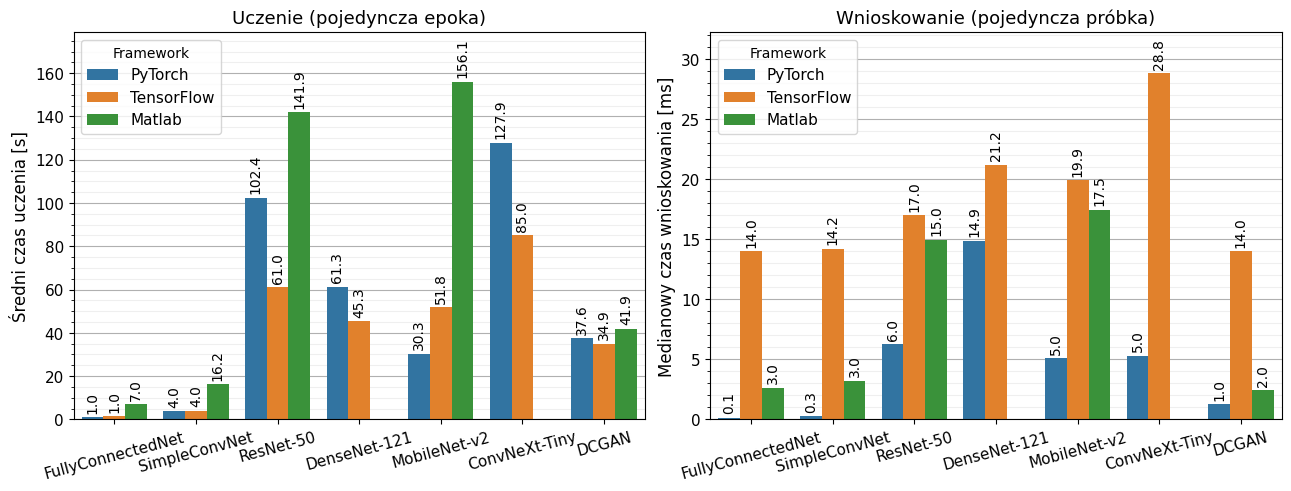

In [48]:
def clf_comp_plot(data: pd.DataFrame, order: list[str], ax: ma._axes.Axes, ylabel: str, title: str):
	sns.barplot(data=data, x="model_name", y="elapsed_time_" + ("median" if "nioskowanie" in title else "mean"), 
			    hue="framework", order=order, zorder=2, ax=ax)
	ax.legend(title="Framework")
	ax.set_xlabel("")
	ax.set_ylabel(ylabel)
	ax.set_title(title)
	ax.set_xticks(ax.get_xticks())
	ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
	ax.grid(axis="y", which="major", zorder=1)
	ax.minorticks_on()
	ax.tick_params(axis='x', which='minor', bottom=False)
	ax.grid(visible=True, axis="y", which="minor", alpha=0.2, zorder=1)
	_, top = ax.get_ylim()
	ax.set_ylim(top=top + (2 if "nioskowanie" in title else 15))
	for container in ax.containers:
		labels = list(map(approx, container.datavalues))
		ax.bar_label(container, labels=labels, padding=3, rotation="vertical")


fig, axes = plt.subplots(1, 2, constrained_layout=True)
fig.set_size_inches(12.8, 4.8)
# fig.suptitle("Porównanie czasu przetwarzania przy klasyfikacji obrazów")

mtdf_clf = mtdf[(mtdf.framework.isin(["PyTorch", "TensorFlow", "Matlab"]))].copy()
clf_comp_plot(mtdf_clf, order=MODEL_ORDER[:-1], ax=axes[0], ylabel="Średni czas uczenia [s]", title="Uczenie (pojedyncza epoka)")

mldf_clf = mldf[(mldf.phase == "latency") & (mldf.framework.isin(["PyTorch", "TensorFlow", "Matlab"]))].copy()
clf_comp_plot(mldf_clf, order=MODEL_ORDER[:-1], ax=axes[1], ylabel="Medianowy czas wnioskowania [ms]", title="Wnioskowanie (pojedyncza próbka)")

fig.savefig("../paper/plots/prezentacja-wyniki-1.png")

In [121]:
def latexify_columns(row: tuple) -> str:
	idx = row[0]
	fields = [f"{float(f):.1f}" for f in row[1:]]
	return f"{idx}\t{' & '.join(fields)} \\\\"

def latexify_df(df: pd.DataFrame) -> None:
	for row in df.itertuples():
		print(latexify_columns(row))

## Uczenie

In [132]:
pd.options.display.float_format = '{:.1f}'.format

training = mtdf[["framework", "model_name", "elapsed_time_mean"]]
training = training.rename({"elapsed_time_mean": "t_mean"}, axis=1)

training

training = training.pivot(index="model_name", columns="framework", values="t_mean")
training = training.rename(
	{"cuDNN": "C/CUDA", "LibTorch": "C++"}, 
	axis=1
)

training["PT_compile_scaled"] = (
	training["PyTorch"] * training["PyTorch_compile"] / training["PyTorch_eager"]
)

training["Python"] = (
	training["PyTorch"]
	+ training["TensorFlow"]
	+ training["PT_compile_scaled"]
) / 3

training = training[[
	"PyTorch", "PT_compile_scaled", "TensorFlow", 
	"Python", "Matlab", "C++", "C/CUDA"]]
training = training.reindex(["FullyConnectedNet", "SimpleConvNet", "ResNet-50", "NativeResNet-50",
				  "DenseNet-121", "MobileNet-v2", "ConvNeXt-Tiny", "DCGAN"])
training

framework,PyTorch,PT_compile_scaled,TensorFlow,Python,Matlab,C++,C/CUDA
model_name,,,,,,,
FullyConnectedNet,1.0,1.0,1.4,1.1,7.1,0.7,0.3
SimpleConvNet,3.8,3.4,4.0,3.7,16.2,3.6,2.6
ResNet-50,102.4,118.5,61.0,94.0,141.9,99.6,NaN
NativeResNet-50,NaN,NaN,NaN,NaN,NaN,91.9,NaN
DenseNet-121,61.3,31.8,45.3,46.1,NaN,60.4,NaN
MobileNet-v2,30.3,23.0,51.8,35.0,156.1,29.5,NaN
ConvNeXt-Tiny,127.9,108.4,85.0,107.1,NaN,124.3,NaN
DCGAN,37.6,37.6,34.9,36.7,41.9,34.6,NaN


In [128]:
latexify_df(training)

FullyConnectedNet	1.1 & 7.1 & 0.7 & 0.3 \\
SimpleConvNet	3.7 & 16.2 & 3.6 & 2.6 \\
ResNet-50	94.0 & 141.9 & 99.6 & nan \\
NativeResNet-50	nan & nan & 91.9 & nan \\
DenseNet-121	46.1 & nan & 60.4 & nan \\
MobileNet-v2	35.0 & 156.1 & 29.5 & nan \\
ConvNeXt-Tiny	107.1 & nan & 124.3 & nan \\
DCGAN	36.7 & 41.9 & 34.6 & nan \\


## Wnioskowanie

In [143]:
inference = mldf[["framework", "model_name", "elapsed_time_median"]]
inference = inference.rename({"elapsed_time_median": "t_median"}, axis=1)

inference = inference.groupby(["framework", "model_name"]).min().reset_index()

inference = inference.pivot(index="model_name", columns="framework", values="t_median")
inference = inference.rename(
	{"cuDNN": "C/CUDA", "LibTorch": "C++"}, 
	axis=1
)

inference["PT_compile_scaled"] = (
	inference["PyTorch"] * inference["PyTorch_compile"] / inference["PyTorch_eager"]
)

inference["Python"] = (
	inference["PyTorch"] +
	inference["TensorFlow"] + 
	inference["PT_compile_scaled"]
) / 3

inference2 = inference

inference = inference[["PyTorch", 				
					    # "PyTorch_eager", "PyTorch_compile",
					   "PT_compile_scaled", "TensorFlow", "Python", 
					 "C++", "Matlab", "C/CUDA"]]
inference = inference.reindex(["FullyConnectedNet", "SimpleConvNet", "ResNet-50", "NativeResNet-50",
				  "DenseNet-121", "MobileNet-v2", "ConvNeXt-Tiny", "DCGAN"])

In [40]:
warmup_cutoff = 1000

pytorch = pd.read_csv('../data/results_ultimate_0/pytorch-yolo.csv')
pytorch["framework"] = pytorch["framework"].apply(lambda x: "PyTorch_eager" if x == "PyTorch" else x)

pt = pd.read_csv("../data/results_ultimate_0/pytorch-yolo-local.csv")
pt = pt[pt.epoch > 1000]

tf = pd.read_csv("../data/results_ultimate_0/tensorflow-yolo-local.csv")
tf["elapsed_time"] = tf["elapsed_time"] / 1e6
tf = tf[tf.epoch > 200]
tf = tf.drop("epoch", axis="columns").reset_index(drop=True).reset_index().rename(columns={"index": "epoch"})
tf["epoch"] += 1001

matlab = pd.read_csv("../data/results_ultimate_0/matlab-yolo-local.csv")
matlab["elapsed_time"] = matlab["elapsed_time"] * 1e3
matlab = matlab[matlab.epoch > 1000]

local_bm = pd.concat([pt, tf, matlab])
local_bm = local_bm.drop(["model_name", "phase", "epoch", "loss", "performance"], axis=1)
g = local_bm.groupby(["framework"])

median = g.median().rename(columns={"elapsed_time": "elapsed_time_median"})
median = median.reset_index()
median["model_name"] = "YOLOv8m"
median["phase"] = "latency"
median["elapsed_time_mean"] = -1
median["elapsed_time_std"] = -1


In [41]:
median

,framework,elapsed_time_median,model_name,phase,elapsed_time_mean,elapsed_time_std
0,Matlab,75.0,YOLOv8m,latency,-1,-1
1,PyTorch,56.0,YOLOv8m,latency,-1,-1
2,TensorFlow,96.0,YOLOv8m,latency,-1,-1


In [140]:
local_bm = pd.concat([pytorch, pt, tf, matlab])
local_bm = local_bm.drop(["model_name", "phase", "epoch", "loss", "performance"], axis=1)
g = local_bm.groupby(["framework"])

median = g.median().rename(columns={"elapsed_time": "t_median"})

median = median.reset_index()
median["model_name"] = "YOLOv8m"
median = median.pivot(index="model_name", columns="framework", values="t_median")

median["PT_compile_scaled"] = (
	median["PyTorch"] * median["PyTorch_compile"] / median["PyTorch_eager"]
)

median["Python"] = (
	median["PyTorch"] +
	median["TensorFlow"] + 
	median["PT_compile_scaled"]
) / 3

median2 = median

median = median[["PyTorch", 
				#  "PyTorch_eager", "PyTorch_compile",
				 "PT_compile_scaled", "TensorFlow", "Python", "Matlab"]]

In [141]:
pd.options.display.float_format = '{:.2f}'.format
latencja = pd.concat([inference, median])[[
	# "PyTorch", "PT_compile_scaled", "TensorFlow", 
	"Python", "Matlab", "C++", "C/CUDA"]]
latencja

framework,Python,Matlab,C++,C/CUDA
model_name,,,,
FullyConnectedNet,4.75,2.62,0.10,0.05
SimpleConvNet,4.90,3.24,0.22,0.13
ResNet-50,8.82,14.96,5.32,NaN
NativeResNet-50,NaN,NaN,4.92,NaN
DenseNet-121,13.50,NaN,8.09,NaN
MobileNet-v2,8.66,17.46,2.56,NaN
ConvNeXt-Tiny,11.91,NaN,3.63,NaN
DCGAN,5.55,2.43,0.83,NaN
YOLOv8m,60.11,74.96,NaN,NaN


In [135]:
latexify_df(latencja)

FullyConnectedNet	4.7 & 2.6 & 0.1 & 0.0 \\
SimpleConvNet	4.9 & 3.2 & 0.2 & 0.1 \\
ResNet-50	8.8 & 15.0 & 5.3 & nan \\
NativeResNet-50	nan & nan & 4.9 & nan \\
DenseNet-121	13.5 & nan & 8.1 & nan \\
MobileNet-v2	8.7 & 17.5 & 2.6 & nan \\
ConvNeXt-Tiny	11.9 & nan & 3.6 & nan \\
DCGAN	5.6 & 2.4 & 0.8 & nan \\
YOLOv8m	60.1 & 75.0 & nan & nan \\


In [147]:
df = inference2[["PT_compile_scaled", "C++", "C/CUDA"]].reindex(["FullyConnectedNet", "SimpleConvNet", "ResNet-50", "NativeResNet-50",
				  "DenseNet-121", "MobileNet-v2", "ConvNeXt-Tiny", "DCGAN"])
df

framework,PT_compile_scaled,C++,C/CUDA
model_name,,,
FullyConnectedNet,0.13,0.10,0.05
SimpleConvNet,0.20,0.22,0.13
ResNet-50,3.20,5.32,NaN
NativeResNet-50,NaN,4.92,NaN
DenseNet-121,4.41,8.09,NaN
MobileNet-v2,0.99,2.56,NaN
ConvNeXt-Tiny,1.63,3.63,NaN
DCGAN,1.42,0.83,NaN


In [152]:
((df["C++"] - df["PT_compile_scaled"]) / df["C++"]).reindex(["SimpleConvNet", "ResNet-50", 
				  "DenseNet-121", "MobileNet-v2", "ConvNeXt-Tiny"]).mean()

np.float64(0.4239784423500598)

In [148]:
latexify_df(df)

FullyConnectedNet	0.1 & 0.1 & 0.0 \\
SimpleConvNet	0.2 & 0.2 & 0.1 \\
ResNet-50	3.2 & 5.3 & nan \\
NativeResNet-50	nan & 4.9 & nan \\
DenseNet-121	4.4 & 8.1 & nan \\
MobileNet-v2	1.0 & 2.6 & nan \\
ConvNeXt-Tiny	1.6 & 3.6 & nan \\
DCGAN	1.4 & 0.8 & nan \\
